In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("C:/Users/alyss/Downloads/OH260225190059543S845PK/CrashStatistics.csv")
df.drop(columns=['LocalReportNumber','DocumentNumber','HitSkip', 'SecondaryCrash','UnitInError','County','FIPSPlaceCode', 'PhotosTaken', 'OH2', 'OH3','OH1P','OHOther','PrivateProperty','ReportingAgencyNCIC','Narrative','ReportTakenBy','Supplement','CrashReportedDateTime','DispatchedDateTime','ArrivedDateTime','SceneClearedDateTime','OtherInvestigationTime','OfficerName','OfficerBadgeNumber','CheckedByOfficerName','CheckedByBadgeNumber'], inplace=True)

C:\Users\alyss\AppData\Local\Temp\ipykernel_38920\1990946857.py:1: DtypeWarning: Columns (0: OfficerBadgeNumber, 1: CheckedByBadgeNumber) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/alyss/Downloads/OH260225190059543S845PK/CrashStatistics.csv")


In [3]:
df["CrashDateTime"] = pd.to_datetime(df["CrashDateTime"])
df["Year"] = df["CrashDateTime"].dt.year
df["Month"] = df["CrashDateTime"].dt.month
df["Day"] = df["CrashDateTime"].dt.day
df["Hour"] = df["CrashDateTime"].dt.hour
df["Minute"] = df["CrashDateTime"].dt.minute
df = df.drop(columns=["CrashDateTime"])

In [4]:
le = LabelEncoder()
df['CrashSeverity'] = le.fit_transform(df['CrashSeverity'])
print(list(df))
print(df.shape[1])

['CrashSeverity', 'LocalInformation', 'NumberOfUnits', 'InCityVillageTownship', 'CityVillageTownshipName', 'Latitude', 'Longitude', 'LocationRouteType', 'LocationRouteNumber', 'LocationPrefix', 'LocationRoadName', 'LocationRoadType', 'DistanceFromReference', 'DistanceReferenceMeasurement', 'DirectionFromReference', 'ReferenceRouteType', 'ReferenceRouteNumber', 'ReferencePrefix', 'ReferenceName', 'ReferencePointUsed', 'ReferenceRoadType', 'IntersectionOrApproachRelated', 'NumberOfApproaches', 'WithinInterchangeArea', 'LocationFirstHarmfulEvent', 'MannerOfCollision', 'Weather', 'LightCondition', 'ActiveSchoolZoneRelated', 'WorkZoneRelated', 'WorkersPresent', 'LawEnforcementPresentInWorkZone', 'WorkZoneType', 'WorkZoneLocation', 'TotalTimeRoadwayClosed', 'RoadwayDivided', 'DividedLaneTravelDirection', 'DividedMedianType', 'RoadContour', 'RoadCondition', 'RoadSurface', 'TotalInjured', 'TotalKilled', 'TotalMinutes', 'AnimalRelated', 'AnimalDeerRelated', 'AlcoholRelated', 'DrugRelated', 'Bic

In [5]:
# List of feature and target columns
x = df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'NumberOfUnits','LightCondition','Weather','MannerOfCollision', 'RoadwayDivided', "IntersectionOrApproachRelated","NumberOfApproaches","WithinInterchangeArea","Latitude","Longitude"]]
y = df['CrashSeverity']

print(x.columns)

Index(['Year', 'Month', 'Day', 'Hour', 'Minute', 'NumberOfUnits',
       'LightCondition', 'Weather', 'MannerOfCollision', 'RoadwayDivided',
       'IntersectionOrApproachRelated', 'NumberOfApproaches',
       'WithinInterchangeArea', 'Latitude', 'Longitude'],
      dtype='str')


In [6]:
#Split testing and training data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print(X_train.columns)


Index(['Year', 'Month', 'Day', 'Hour', 'Minute', 'NumberOfUnits',
       'LightCondition', 'Weather', 'MannerOfCollision', 'RoadwayDivided',
       'IntersectionOrApproachRelated', 'NumberOfApproaches',
       'WithinInterchangeArea', 'Latitude', 'Longitude'],
      dtype='str')


In [7]:
#Separate numeric and categorical features
numeric_features = x.select_dtypes(include="number").columns
categorical_features = x.select_dtypes(exclude="number").columns
print(numeric_features)
print(categorical_features)

Index(['Year', 'Month', 'Day', 'Hour', 'Minute', 'NumberOfUnits',
       'NumberOfApproaches', 'Latitude', 'Longitude'],
      dtype='str')
Index(['LightCondition', 'Weather', 'MannerOfCollision', 'RoadwayDivided',
       'IntersectionOrApproachRelated', 'WithinInterchangeArea'],
      dtype='str')


Core code

In [32]:
import sklearn.preprocessing as pre
from sklearn.compose import ColumnTransformer

#("imputer", SimpleImputer(strategy="median")),
data_transformer = ColumnTransformer(
  transformers = [
    ('rescale numeric', pre.StandardScaler(), numeric_features),
    ('recode categorical', 
      pre.OneHotEncoder(handle_unknown = 'ignore'), 
      categorical_features)
    ])

transformed_data = data_transformer.fit_transform(X_train)

column_names = data_transformer.get_feature_names_out()

#print(len(column_names)) - 40
print(column_names) 
# creates a different one for each 


# Create and print the DataFrame
#df_transformed = pd.DataFrame(transformed_data, columns=column_names)
#print(df_transformed.head())



['rescale numeric__Year' 'rescale numeric__Month' 'rescale numeric__Day'
 'rescale numeric__Hour' 'rescale numeric__Minute'
 'rescale numeric__NumberOfUnits' 'rescale numeric__NumberOfApproaches'
 'rescale numeric__Latitude' 'rescale numeric__Longitude'
 'recode categorical__LightCondition_Dark - Lighted Roadway'
 'recode categorical__LightCondition_Dark - Roadway Not Lighted'
 'recode categorical__LightCondition_Dark - Unknown Roadway Lighting'
 'recode categorical__LightCondition_Dawn/Dusk'
 'recode categorical__LightCondition_Daylight'
 'recode categorical__LightCondition_Other/Unknown'
 'recode categorical__Weather_Blowing Sand; Soil; Dirt; Snow'
 'recode categorical__Weather_Clear' 'recode categorical__Weather_Cloudy'
 'recode categorical__Weather_Fog; Smog; Smoke'
 'recode categorical__Weather_Freezing Rain or Freezing Drizzle'
 'recode categorical__Weather_Other/Unknown'
 'recode categorical__Weather_Rain'
 'recode categorical__Weather_Severe Crosswinds'
 'recode categorical__We

In [9]:
#Feature selection
from sklearn.feature_selection import SelectFromModel
feature_selector = SelectFromModel(
    estimator=XGBClassifier(
        n_estimators=200,
        eval_metric="logloss",
        random_state=42
    ),
    threshold="median"
)

In [10]:
model_1 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

In [11]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth=4,
    random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
xgb_pipeline =  Pipeline(steps = [
    ('preprocessing', data_transformer),
    ("feature_selection", feature_selector),
    ('XGB', model_1)
    ])

xgb_pipeline = xgb_pipeline.fit(X_train, y_train)
prediction = xgb_pipeline.predict(X_test)

print(*prediction)
print("Test accuracy:", xgb_pipeline.score(X_test, y_test))



3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 0 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 

In [ ]:
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps = [
    ('preprocessing', data_transformer),
    ('feature_selection', feature_selector),
    ('RF', rf_model)
    ])

rf_pipeline = rf_pipeline.fit(X_train, y_train)
rf_predict = rf_pipeline.predict(X_test)

print(rf_predict)
print("Test accuracy: ", rf_pipeline.score(X_test, y_test))

TypeError: ForestClassifier.predict() got an unexpected keyword argument 'pred_contribs'

Attempting to print feature importance

In [ ]:
print(f"Feature importances: {model_1.feature_importances_}")
print("Feature importance length: "+str(len(model_1.feature_importances_)))
print("Features length: "+str(len(x.columns)))

#Notes: it stores the result from the pipeline and calls model_1 that has already been fitted with the previous kernel

feature_list = model_1.get_booster().feature_names
print(feature_list)

original_feature_names = X_train.columns.tolist()
print(original_feature_names)

importances = model_1.feature_importances_
feature_importance_df = pd.DataFrame(zip(column_names, importances), columns=['feature', 'importance']).set_index('feature')
print(feature_importance_df)

Feature importances: [0.03260456 0.06425821 0.04185994 0.04013828 0.04037003 0.03033571
 0.02787068 0.04698698 0.02721424 0.02810934 0.03029735 0.08062055
 0.08610881 0.08482152 0.05342366 0.04732587 0.05805133 0.10325874
 0.05623537 0.02010888]
Feature importance length: 20
Features length: 15
None
['Year', 'Month', 'Day', 'Hour', 'Minute', 'NumberOfUnits', 'LightCondition', 'Weather', 'MannerOfCollision', 'RoadwayDivided', 'IntersectionOrApproachRelated', 'NumberOfApproaches', 'WithinInterchangeArea', 'Latitude', 'Longitude']
                                                    importance
feature                                                       
rescale numeric__Year                                 0.032605
rescale numeric__Month                                0.064258
rescale numeric__Day                                  0.041860
rescale numeric__Hour                                 0.040138
rescale numeric__Minute                               0.040370
rescale numeric__NumberOf

In [42]:
clf = XGBClassifier(n_estimators=5, random_state=42)
clf = clf.fit(transformed_data, y_train)

#feature_list = clf.get_booster().feature_names

#print(feature_list)

importances = clf.feature_importances_
column_names = data_transformer.get_feature_names_out()

#print(f"Feature importances: {clf.feature_importances_}")
#print("Feature importance length: "+str(len(clf.feature_importances_)))
#print("Features length: "+str(len(x.columns)))

feature_importance_df = pd.DataFrame(zip(column_names, importances), columns=['feature', 'importance']).set_index('feature')
df_sorted = feature_importance_df.sort_values(by='importance', ascending=False)
print(df_sorted)



                                                    importance
feature                                                       
recode categorical__MannerOfCollision_Sideswipe...    0.109353
recode categorical__MannerOfCollision_Backing         0.093563
recode categorical__MannerOfCollision_Head-on         0.086803
recode categorical__MannerOfCollision_Angle           0.070836
rescale numeric__NumberOfUnits                        0.064855
recode categorical__MannerOfCollision_Not Colli...    0.057058
recode categorical__LightCondition_Daylight           0.053371
recode categorical__RoadwayDivided_False              0.046102
recode categorical__MannerOfCollision_Sideswipe...    0.043010
recode categorical__MannerOfCollision_Rear-end        0.041397
rescale numeric__NumberOfApproaches                   0.037788
recode categorical__LightCondition_Dark - Roadw...    0.032405
rescale numeric__Longitude                            0.030466
rescale numeric__Latitude                             0

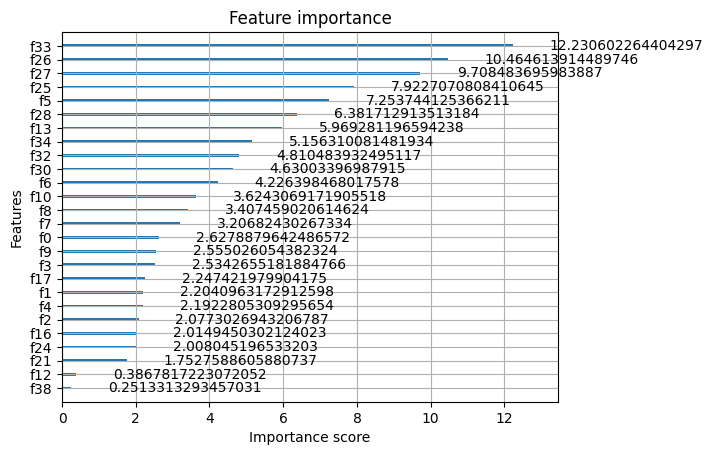

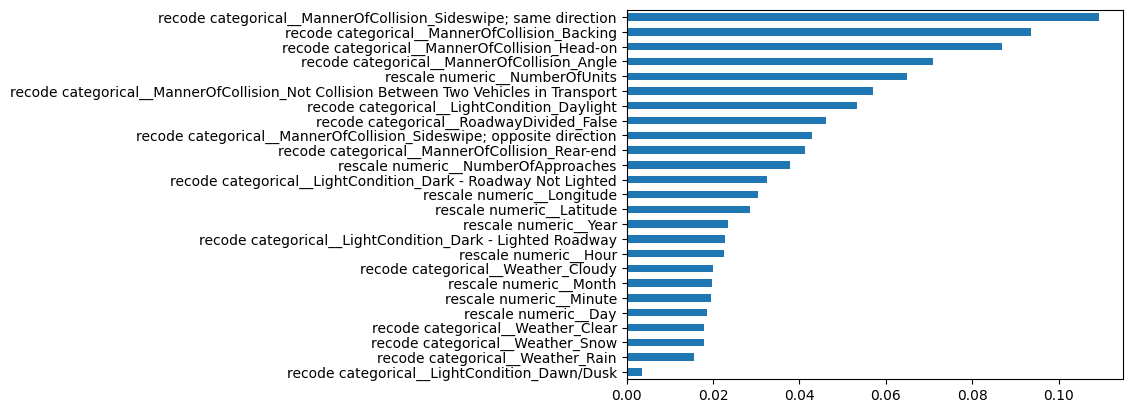

In [47]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(clf.get_booster(), importance_type='gain')
plt.show()

pd.Series(clf.feature_importances_, index=column_names).nlargest(25).plot(kind='barh').invert_yaxis()

In [ ]:
# Get feature importances
importances = model_1.feature_importances_

# Map to names and sort
feature_imp_df = pd.DataFrame({'Feature': x.columns, 'Importance': importances})
new_feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)
print(new_feature_imp_df)

In [ ]:

# 3. Use SelectFromModel to select features based on the trained estimator
# By default, the threshold is the mean of the feature importances
model_selection = SelectFromModel(clf, prefit=True) 

X_train_selected = model_selection.transform(transformed_data)
print(X_train_selected)

selected_feature_indices = model_selection.get_support(indices=True)
selected_feature_names = [X_train_selected[i] for i in selected_feature_indices]
#print("Selected feature names:", selected_feature_names)


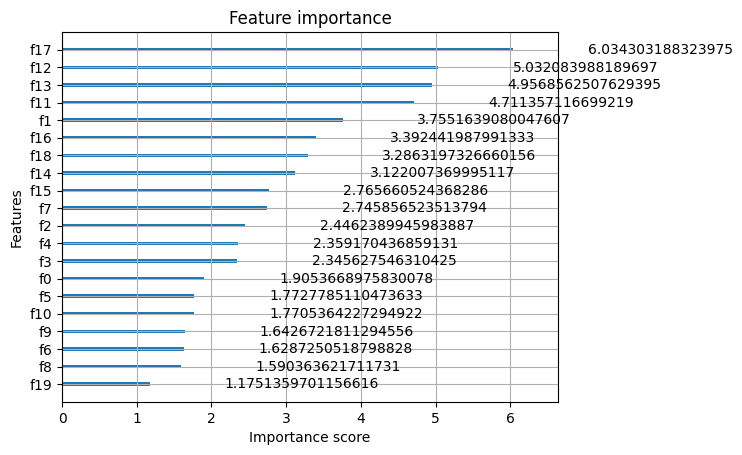

In [25]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

#print(model_1.feature_names_in_)
#feat_importances = pd.Series(model.feature_importances_, index=X_train.columns)
plot_importance(model_1.get_booster(), importance_type='gain')
plt.show()